# Aim 3
Tara Cornwell June 2024

Adapted from Darici and Kuo

### First, let's simulate a baseline, unperturbed step condition.

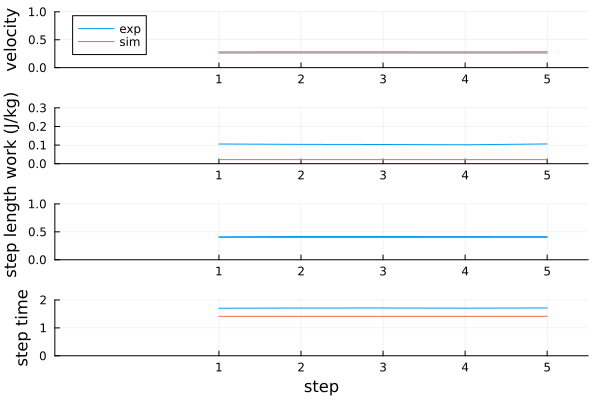

In [2]:
# Import necessary packages
using DynLoco_TC, Plots, CSV, DataFrames, Statistics, StructArrays

# Import experimental data
df_M_N = CSV.read("M_N.csv", header=["kg"], DataFrame) # mass
df_H_N = CSV.read("H_N.csv", header=["m"], DataFrame) # height
#df_M_S = CSV.read("M_S.csv", header=["kg"], DataFrame) # mass
#df_H_S = CSV.read("H_S.csv", header=["m"], DataFrame) # height

df_V_N_B = CSV.read("V_N1.csv", header=["V","V","V","V","V"], DataFrame) # velocities
df_U_N_B = CSV.read("U_N1.csv", header=["U","U","U","U","U"], DataFrame) # positive work
df_SL_N_B = CSV.read("SL_N1.csv", header=["SL","SL","SL","SL","SL"], DataFrame) # step lengths
df_ST_N_B = CSV.read("ST_N1.csv", header=["ST","ST","ST","ST","ST"], DataFrame) # step times

v = Matrix(df_V_N_B)
u = Matrix(df_U_N_B)
sl = Matrix(df_SL_N_B)
st = Matrix(df_ST_N_B)

# Set number of steps: pre, pert, recovery
nsteps = 5

# Plots
l = @layout [a; b; c; d]

g = 9.81
L = 1
M = 1
norm_u = g*L # already mass-normalized
subj=1

# Clear variables
wstar_N = nothing
c = nothing
a = nothing
nominal = nothing

# Create structure for "walk"
c = mean(sl[subj,:])/(mean(v[subj,:])^0.54)
a = asin(mean(sl[subj,:])/(2L))
wstar_N = findgait(WalkRW2lvs(α=a,c=c,safety=true), target=:speed=>mean(v[subj,:]), varying=:P)
nominal = optwalk_TC(wstar_N, nsteps, boundaryvels = (wstar_N.vm, wstar_N.vm), boundarywork=false)

p1 = plot(v[subj,:], ylabel="velocity", label="exp", legend=:left)
plot!(p1, nominal.steps.vm, label="sim")
plot!(p1, xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(u[subj,:], ylabel="work (J/kg)", label=false)
plot!(p2, nominal.steps.Pwork.*norm_u, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.3), xticks = 1:1:nsteps, yticks = 0:0.1:0.3)

p3 = plot(sl[subj,:], ylabel="step length", label=false)
plot!(p3, nominal.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p4 = plot(st[subj,:], xlabel="step", ylabel="step time", label=false)
plot!(p4, nominal.steps.tf, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2), xticks = 1:1:nsteps, yticks = 0:1:2)

plot(p1, p2, p3, p4, layout = l)

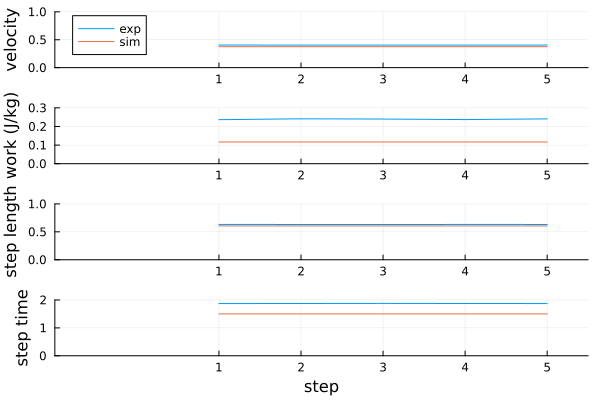

In [3]:
# Group plot

# Clear variables
wstar_N = nothing
c = nothing
a = nothing
nominal = nothing

# Create structure for "walk"
c = mean(sl[:,:])/(mean(v[:,:])^0.54)
a = asin(mean(sl[:,:])/(2L))
wstar_N = findgait(WalkRW2lvs(α=a,c=c,safety=true), target=:speed=>mean(v[:,:]), varying=:P)
nominal = optwalk_TC(wstar_N, nsteps, boundaryvels = (wstar_N.vm, wstar_N.vm), boundarywork=false)

p1 = plot(mean(v[:,:],dims=1)', ylabel="velocity", label="exp", legend=:left)
plot!(p1, nominal.steps.vm, label="sim")
plot!(p1, xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mean(u[:,:],dims=1)', ylabel="work (J/kg)", label=false)
plot!(p2, nominal.steps.Pwork.*norm_u, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.3), xticks = 1:1:nsteps, yticks = 0:0.1:0.3)

p3 = plot(mean(sl[:,:],dims=1)', ylabel="step length", label=false)
plot!(p3, nominal.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p4 = plot(mean(st[:,:],dims=1)', xlabel="step", ylabel="step time", label=false)
plot!(p4, nominal.steps.tf, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2), xticks = 1:1:nsteps, yticks = 0:1:2)

plot(p1, p2, p3, p4, layout = l)

## Compare unexpected vs. expected perturbations experimentally.

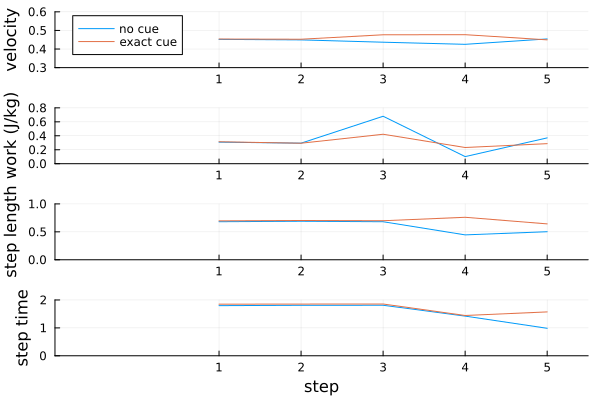

In [83]:
# Import experimental data
# AIM 1
df_V_N_rand = CSV.read("V_N5.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_N_rand = CSV.read("U_N5.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_N_rand = CSV.read("SL_N5.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_N_rand = CSV.read("ST_N5.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

df_V_N_reg = CSV.read("V_N8.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_N_reg = CSV.read("U_N8.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_N_reg = CSV.read("SL_N8.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_N_reg = CSV.read("ST_N8.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

v5 = Matrix(df_V_N_rand)
u5 = Matrix(df_U_N_rand)
sl5 = Matrix(df_SL_N_rand)
st5 = Matrix(df_ST_N_rand)

v8 = Matrix(df_V_N_reg)
u8 = Matrix(df_U_N_reg)
sl8 = Matrix(df_SL_N_reg)
st8 = Matrix(df_ST_N_reg)

# AIM 2
df_V_N_W0 = CSV.read("V_N9.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_N_W0 = CSV.read("U_N9.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_N_W0 = CSV.read("SL_N9.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_N_W0 = CSV.read("ST_N9.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

df_V_N_W2 = CSV.read("V_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_N_W2 = CSV.read("U_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_N_W2 = CSV.read("SL_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_N_W2 = CSV.read("ST_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

v0 = Matrix(df_V_N_W0)
u0 = Matrix(df_U_N_W0)
sl0 = Matrix(df_SL_N_W0)
st0 = Matrix(df_ST_N_W0)

v2 = Matrix(df_V_N_W2)
u2 = Matrix(df_U_N_W2)
sl2 = Matrix(df_SL_N_W2)
st2 = Matrix(df_ST_N_W2)

subj=13

# Plots - No vs. exact cue for individual
l = @layout [a; b; c; d]
p1 = plot(v0[subj,2:6], ylabel="velocity", label="no cue", legend=:left)
plot!(p1, v2[subj,2:6], label="exact cue")
plot!(p1, xlims = (-1, nsteps+0.5), ylims = (0.3, 0.6), xticks = 1:1:nsteps, yticks = 0.3:0.1:0.6)

p2 = plot(u0[subj,2:6], ylabel="work (J/kg)", label=false)
plot!(p2, u2[subj,2:6], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.8), xticks = 1:1:nsteps, yticks = 0:0.2:0.8)

p3 = plot(sl0[subj,2:6], ylabel="step length", label=false)
plot!(p3, sl2[subj,2:6], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p4 = plot(st0[subj,2:6], xlabel="step", ylabel="step time", label=false)
plot!(p4, st2[subj,2:6], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2), xticks = 1:1:nsteps, yticks = 0:1:2)

plot(p1, p2, p3, p4, layout = l)

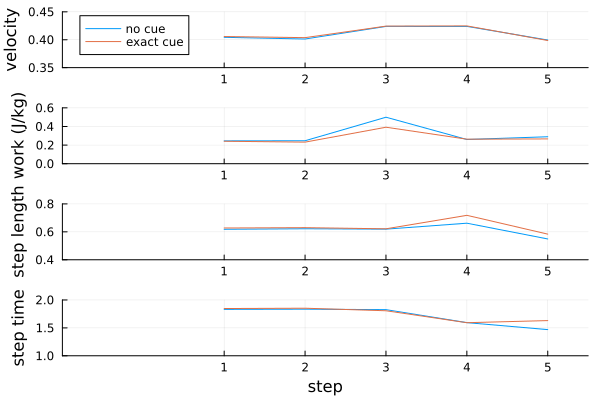

In [79]:
# Group plot - No vs. exact cue
p1 = plot(mean(v0[:,2:6],dims=1)', ylabel="velocity", label="no cue", legend=:left)
plot!(p1, mean(v2[:,2:6],dims=1)', label="exact cue")
plot!(p1, xlims = (-1, nsteps+0.5), ylims = (0.35, 0.45), xticks = 1:1:nsteps, yticks = 0.35:0.05:0.45)

p2 = plot(mean(u0[:,2:6],dims=1)', ylabel="work (J/kg)", label=false)
plot!(p2, mean(u2[:,2:6],dims=1)', label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.6), xticks = 1:1:nsteps, yticks = 0:0.2:0.6)

p3 = plot(mean(sl0[:,2:6],dims=1)', ylabel="step length", label=false)
plot!(p3, mean(sl2[:,2:6],dims=1)', label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0.4, 0.8), xticks = 1:1:nsteps, yticks = 0.4:0.2:0.8)

p4 = plot(mean(st0[:,2:6],dims=1)', xlabel="step", ylabel="step time", label=false)
plot!(p4, mean(st2[:,2:6],dims=1)', label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (1, 2), xticks = 1:1:nsteps, yticks = 1:0.5:2)

plot(p1, p2, p3, p4, layout = l)

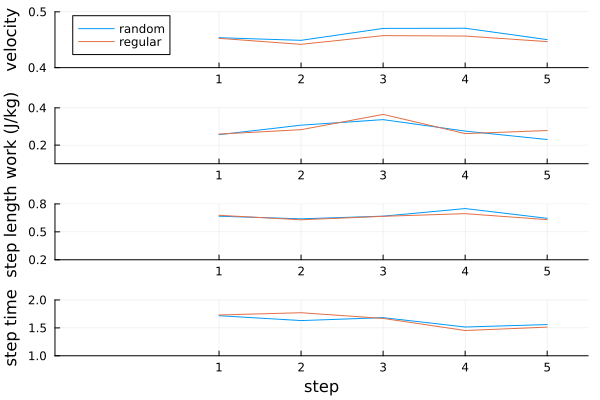

In [74]:
# Compare random vs. regular - individual

subj=13

# Plots
l = @layout [a; b; c; d]
p1 = plot(v5[subj,2:6], ylabel="velocity", label="random", legend=:left)
plot!(p1, v8[subj,2:6], label="regular")
plot!(p1, xlims = (-1, nsteps+0.5), ylims = (0.4, 0.5), xticks = 1:1:nsteps, yticks = 0.3:0.1:0.6)

p2 = plot(u5[subj,2:6], ylabel="work (J/kg)", label=false)
plot!(p2, u8[subj,2:6], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0.1, 0.4), xticks = 1:1:nsteps, yticks = 0:0.2:0.8)

p3 = plot(sl5[subj,2:6], ylabel="step length", label=false)
plot!(p3, sl8[subj,2:6], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0.2, 0.8), xticks = 1:1:nsteps, yticks = 0.2:0.3:0.8)

p4 = plot(st5[subj,2:6], xlabel="step", ylabel="step time", label=false)
plot!(p4, st8[subj,2:6], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (1, 2), xticks = 1:1:nsteps, yticks = 1:0.5:2)

plot(p1, p2, p3, p4, layout = l)

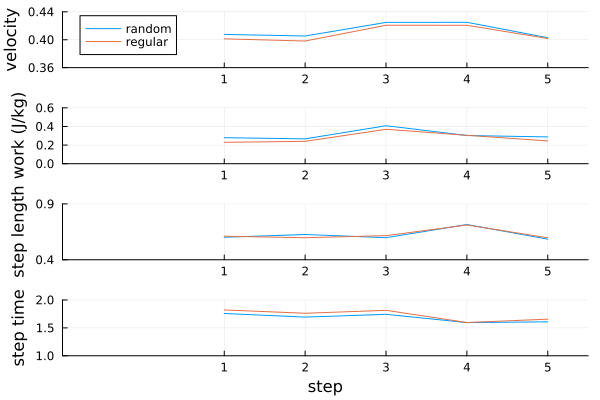

In [65]:
# Group plot - random vs. regular
p1 = plot(mean(v5[:,2:6],dims=1)', ylabel="velocity", label="random", legend=:left)
plot!(p1, mean(v8[:,2:6],dims=1)', label="regular")
plot!(p1, xlims = (-1, nsteps+0.5), ylims = (0.36, 0.44), xticks = 1:1:nsteps, yticks = 0.36:0.04:0.44)

p2 = plot(mean(u5[:,2:6],dims=1)', ylabel="work (J/kg)", label=false)
plot!(p2, mean(u8[:,2:6],dims=1)', label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.6), xticks = 1:1:nsteps, yticks = 0:0.2:0.6)

p3 = plot(mean(sl5[:,2:6],dims=1)', ylabel="step length", label=false)
plot!(p3, mean(sl8[:,2:6],dims=1)', label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0.4, 0.9), xticks = 1:1:nsteps, yticks = 0.4:0.5:0.9)

p4 = plot(mean(st5[:,2:6],dims=1)', xlabel="step", ylabel="step time", label=false)
plot!(p4, mean(st8[:,2:6],dims=1)', label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (1, 2), xticks = 1:1:nsteps, yticks = 1:0.5:2)

plot(p1, p2, p3, p4, layout = l)

### Now let's simulate a perturbation with 1) naive and 2) completely reactive control.

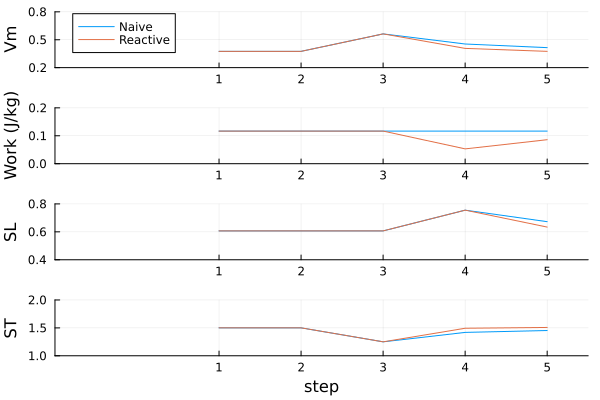

In [19]:
using DynLoco_TC, Plots

# Setup perturbation vector
nsteps = 5
perts = [1 1 1.5 1 1]

# Clear variables
wstar_N = nothing
c = nothing
a = nothing
nominal = nothing
g = 9.81
L = 1
M = 1
norm_u = g*L # already mass-normalized

# Create structure for "walk"
c = mean(sl[:,:])/(mean(v[:,:])^0.54)
a = asin(mean(sl[:,:])/(2L))
wstar_N = findgait(WalkRW2lvs(α=a,c=c,safety=true), target=:speed=>mean(v[:,:]), varying=:P)

# Plots
l = @layout [a; b; c; d]

p1 = plot(xlims = (-1, nsteps+0.5), ylims = (0.2, 0.8), xticks = 1:1:nsteps, yticks = 0.2:0.3:0.8)
p2 = plot(xlims = (-1, nsteps+0.5), ylims = (0, 0.2), xticks = 1:1:nsteps, yticks = 0:0.1:0.2)
p3 = plot(xlims = (-1, nsteps+0.5), ylims = (0.4, 0.8), xticks = 1:1:nsteps, yticks = 0.4:0.2:0.8)
p4 = plot(xlims = (-1, nsteps+0.5), ylims = (1, 2), xticks = 1:1:nsteps, yticks = 1:0.5:2)

# Nominal, unperturbed
nominal = optwalk_TC(wstar_N, nsteps, boundaryvels=(wstar_N.vm, wstar_N.vm), boundarywork=false)

# Apply naive control to perturbation condition
naive = multistep(wstar_N, Ps=nominal.steps.P, perts=perts)
plot!(p1, naive.steps.vm, ylabel="Vm", label="Naive", legend=:topleft)
plot!(p2, naive.steps.Pwork*norm_u, ylabel="Work (J/kg)", label=false)
plot!(p3, naive.steps.steplength, ylabel="SL", label=false)
plot!(p4, naive.steps.tf, xlabel="step", ylabel="ST", label=false)

# No anticipatory control - just react after the perturbation happens
reactive_1 = multistep(wstar_N, Ps=nominal.steps.P[1:3], perts = [1 1 1.5])
reactive_2 = optwalk_TC(wstar_N, nsteps-3, boundaryvels=(reactive_1.steps[end].vm,wstar_N.vm), boundarywork=false, perts=[1 1])
plot!(p1, [reactive_1.steps.vm; reactive_2.steps.vm], ylabel="Vm", label="Reactive", legend=:topleft)
plot!(p2, [reactive_1.steps.Pwork; reactive_2.steps.Pwork]*norm_u, ylabel="Work (J/kg)", label=false)
plot!(p3, [reactive_1.steps.steplength; reactive_2.steps.steplength], ylabel="SL", label=false)
plot!(p4, [reactive_1.steps.tf; reactive_2.steps.tf], xlabel="step", ylabel="ST", label=false)

plot(p1, p2, p3, p4, layout = l)

### Optimize entire trajectory (proactive control) minimizing different Js

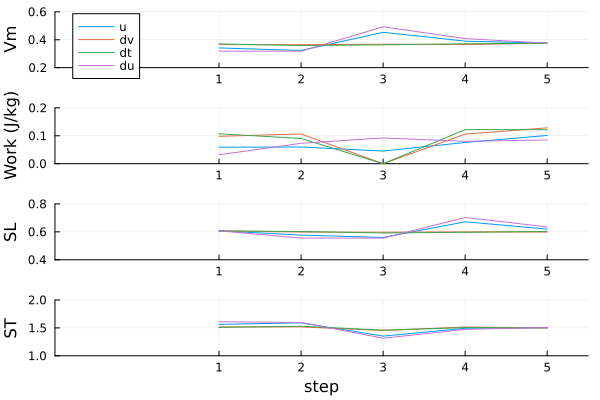

In [23]:
# Plots
l = @layout [a; b; c; d]

p1 = plot(xlims = (-1, nsteps+0.5), ylims = (0.2, 0.6), xticks = 1:1:nsteps, yticks = 0.2:0.2:0.6)
p2 = plot(xlims = (-1, nsteps+0.5), ylims = (0, 0.2), xticks = 1:1:nsteps, yticks = 0:0.1:0.2)
p3 = plot(xlims = (-1, nsteps+0.5), ylims = (0.4, 0.8), xticks = 1:1:nsteps, yticks = 0.4:0.2:0.8)
p4 = plot(xlims = (-1, nsteps+0.5), ylims = (1, 2), xticks = 1:1:nsteps, yticks = 1:0.5:2)

L = 1
M = 1
norm_u = g*L # already mass-normalized

for J = ["u","dv","dt","du"]
    temp = nothing
    temp = optwalk_TC(wstar_N, nsteps, boundaryvels=(wstar_N.vm,wstar_N.vm), boundarywork=false, perts=perts, J=J)
    plot!(p1, temp.steps.vm, ylabel="Vm", label=J, legend=:topleft)
    plot!(p2, temp.steps.Pwork*norm_u, ylabel="Work (J/kg)", label=false)
    plot!(p3, temp.steps.steplength, ylabel="SL", label=false)
    plot!(p4, temp.steps.tf, xlabel="step", ylabel="ST", label=false)
end
plot(p1, p2, p3, p4, layout = l)

### Let's try the weighted sum J with varied weight.

In [ ]:
using DynLoco_TC, Plots, CSV, DataFrames, Statistics, StructArrays

results_pert = nothing
results_pert = DataFrame(J=String[], weight=Float64[], vm=Vector[], u=Vector[], SL=Vector[])

# Plots
l = @layout [a; b; c]

p1 = plot(xlims = (-1, nsteps+0.5), ylims = (0, 0.8), xticks = 1:1:nsteps, yticks = 0:0.4:0.8)
p2 = plot(xlims = (-1, nsteps+0.5), ylims = (0, 0.04), xticks = 1:1:nsteps, yticks = 0:0.01:0.04)
p3 = plot(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

J = "sum"
for weight = [0 0.5 0.99 1]
    temp = optwalk_TC(wstar_N, nsteps, boundarywork=false, perts=perts, J=J, weight=weight)
    push!(results_pert, (J, weight, temp.steps.vm, temp.steps.Pwork, temp.steps.steplength))
    plot!(p1, temp.steps.vm, ylabel="Vm", label=weight, legend=:topleft)
    plot!(p2, temp.steps.Pwork, ylabel="Push-off work", label=false)
    plot!(p3, temp.steps.steplength, xlabel="step", ylabel="SL", label=false)
end

plot(p1, p2, p3, layout = l)

### Now let's try using the MPC controller.

In [ ]:
# Run optimization that minimizes push-off work
mpc_result1 = mpcstep(wstar_N, nsteps, 1, perts=perts)
mpc_result2 = mpcstep(wstar_N, nsteps, 2, perts=perts)
mpc_result3 = mpcstep(wstar_N, nsteps, 3, perts=perts)

nhorizon=nsteps
mpc_result_full = mpcstep(wstar_N, nsteps, nhorizon, perts=perts)

# Print results
println("With horizon = 1, PO work cost = ", mpc_result1.workcost)
println("With horizon = 2, PO work cost = ", mpc_result2.workcost)
println("With horizon = 3, PO work cost = ", mpc_result3.workcost)
println("With full horizon, PO work cost = ", mpc_result_full.workcost)

# Plots
l = @layout [a; b; c]

p1 = plot(mpc_result1.steps.vm, label="nh=1")
#plot!(mpc_result2.steps.vm, label="nh=2")
#plot!(mpc_result3.steps.vm, label="nh=3")
plot!(mpc_result_full.steps.vm, ylabel="Vmidstance", label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mpc_result1.steps.Pwork, ylabel="Push-off work", label="nh=1")
#plot!(mpc_result2.steps.Pwork, label="nh=2")
#plot!(mpc_result3.steps.Pwork, label="nh=3")
plot!(mpc_result_full.steps.Pwork, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(mpc_result1.steps.steplength, xlabel="step", ylabel="Time", label="nh=1")
#plot!(mpc_result2.steps.steplength, label="nh=2")
#plot!(mpc_result3.steps.steplength, label="nh=3")
plot!(mpc_result_full.steps.steplength, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### Test different objective functions

In [ ]:
nhorizon=nsteps
min_P = zeros(nsteps)

#result_0 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0)
#result_1 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=1)
#result_5 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0.5)
#result_8 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0.8)
#result_01 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0.1)

result_u = Nothing
result_dt = Nothing
result_dv = Nothing

result_u = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="u", min_P=min_P)
result_dt = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="dt", min_P=min_P)
result_dv = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="dv", min_P=min_P)
#result_du = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="du", min_P=minP)

# Print results
println("Min. work, work cost = ", result_u.workcost)
println("Min. changes in step time, work cost = ", result_dt.workcost)
println("Min. changes in velocity, work cost = ", result_dv.workcost)
#println("Min. changes in work, J = ", result_du.workcost)

# Plots
l = @layout [a; b; c]

p1 = plot(result_u.steps.vm, ylabel="Vmidstance", label="u")
plot!(result_dt.steps.vm, label="dt")
plot!(result_dv.steps.vm, label="dv")
#plot!(result_du.steps.vm, label="du")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.5), xticks = 1:1:nsteps, yticks = 0:0.1:0.5)

p2 = plot(result_u.steps.Pwork, ylabel="Push-off work", label=false)
plot!(result_dt.steps.Pwork, label=false)
plot!(result_dv.steps.Pwork, label=false)
#plot!(result_du.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.03), xticks = 1:1:nsteps, yticks = 0:0.01:0.03)

#p3 = plot(result_0.steps.tf, ylabel="Time", label="w=0")
#plot!(result_01.steps.tf, label="w=0.1")
#plot!(result_5.steps.tf, label="w=0.5")
#plot!(result_8.steps.tf, label="w=0.8")
#plot!(result_1.steps.tf, label="w=1")
#plot!(xlims = (-1, nsteps+0.5), xticks = 1:1:nsteps)
#plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2.5), xticks = 1:1:nsteps, yticks = 0:0.5:2.5)

p4 = plot(result_u.steps.steplength, xlabel="step", ylabel="Step length", label=false)
plot!(result_dt.steps.steplength, label=false)
plot!(result_dv.steps.steplength, label=false)
#plot!(result_du.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p4, layout = l)

In [ ]:
# Import experimental data
using CSV, DataFrames, Plots, Statistics

df_V_NW2 = CSV.read("V_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_NW2 = CSV.read("U_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_NW2 = CSV.read("SL_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_NW2 = CSV.read("ST_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

#df_V_SW2 = CSV.read("V_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
#df_U_SW2 = CSV.read("U_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
#df_SL_SW2 = CSV.read("SL_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
#df_ST_SW2 = CSV.read("ST_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

# Plots
l = @layout [a; b; c]

g = 9.81
L = 1
M = 1
norm_u = g*L # already mass-normalized

p1 = plot(mean(transpose(Matrix(df_V_NW2[:,2:6])),dims=2), linecolor =:black, ylabel="velocity", label="non-stroke",legend=:left)
#plot!(mean(transpose(Matrix(df_V_SW2[:,2:6])),dims=2), linecolor =:black, linestyle=:dash, label="stroke")
plot!(result_u.steps.vm, label="h=full; min(u)")
plot!(result_dt.steps.vm, label="h=full; min(dt)")
plot!(result_dv.steps.vm, label="h=full; min(dv)")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mean(transpose(Matrix(df_U_NW2[:,1:5])),dims=2)/norm_u, linecolor =:black, ylabel="work (J/kg)", label=false)
#plot!(mean(transpose(Matrix(df_U_SW2[:,1:5])),dims=2)/norm_u, linecolor =:black, linestyle=:dash, label=false)
plot!(result_u.steps.Pwork, label=false)
plot!(result_dt.steps.Pwork, label=false)
plot!(result_dv.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.05), xticks = 1:1:nsteps, yticks = 0:0.01:0.05)

p3 = plot(mean(transpose(Matrix(df_SL_NW2[:,2:6])),dims=2), linecolor =:black, xlabel="step", ylabel="step length", label=false)
#plot!(mean(transpose(Matrix(df_SL_SW2[:,2:6])),dims=2), linecolor =:black, linestyle=:dash, label=false)
plot!(result_u.steps.steplength, xlabel="step", label=false)
plot!(result_dt.steps.steplength, xlabel="step", label=false)
plot!(result_dv.steps.steplength, xlabel="step", label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### Correlations between experimental and simulation results

In [ ]:
using Statistics, Plots, StatsPlots, GLM, StatsBase
l = @layout [a; b; c]

# VM
x = mean(transpose(Matrix(df_V_NW2[:,2:6])),dims=2)

y = result_u.steps.vm
z=cor(x,y)[1]
#scatter(x,y)
#p1 = plot!()
p1 = plot(x,y,markershape=:circle,title="Vmidstance",label=round(z,digits=2),legend=:outertopright)

y = result_dt.steps.vm
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

y = [reactive_result1.steps.vm; reactive_result2.steps.vm]
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

# WORK
x = mean(transpose(Matrix(df_U_NW2[:,1:5])),dims=2)/norm_u

y = result_u.steps.Pwork
z=cor(x,y)[1]
p2 = plot(x,y,markershape=:circle,ylabel="Simulation",title="Push-off work",label=round(z,digits=2),legend=:outertopright)

y = result_dt.steps.Pwork
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

y = [reactive_result1.steps.Pwork; reactive_result2.steps.Pwork]
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

# SL
x = mean(transpose(Matrix(df_SL_NW2[:,2:6])),dims=2)

y = result_u.steps.steplength
z=cor(x,y)[1]
p3 = plot(x,y,markershape=:circle,xlabel="Experimental",title="Step length",label=round(z,digits=2),legend=:outertopright)

y = result_dt.steps.steplength
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

y = [reactive_result1.steps.steplength; reactive_result2.steps.steplength]
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

plot(p1, p2, p3, layout = l)

In [ ]:
# Set up AIC to compare models

using Statistics, Plots, StatsPlots, GLM, StatsBase
xx = mean(transpose(Matrix(df_V_NW2[:,2:6])),dims=2)
yy = Float64.(result_u.steps.vm)
yy = reshape(yy, length(yy), 1)

data = DataFrame(x=xx[1:5], y=yy[1:5])
mdl = lm(@formula(y ~ x), data)
println(round(aic(mdl); digits=3))


yy = Float64.(result_dt.steps.vm)
yy = reshape(yy, length(yy), 1)

data = DataFrame(x=xx[1:5], y=yy[1:5])
mdl = lm(@formula(y ~ x), data)
println(round(aic(mdl); digits=3))


yy = Float64.(result_dv.steps.vm)
yy = reshape(yy, length(yy), 1)

data = DataFrame(x=xx[1:5], y=yy[1:5])
mdl = lm(@formula(y ~ x), data)
println(round(aic(mdl); digits=3))

### Start simulating stroke impairment
Testing bounding max on push-off work for one leg.

In [ ]:
# Clear variables
wstar_S = nothing

# Create structure for "walk"
wstar_S = findgait(WalkRW2lvs(α=0.19,safety=true), target=:speed=>0.30, varying=:P)

# Not impaired
nominal_S = optwalk_TC(wstar_S, nsteps, boundarywork=false)

# Impaired but not optimal
percents = [1 0.75 1 0.75 1]
limit_Ps = nominal_S.steps.P.*percents'
impaired = multistep(wstar_S, Ps=limit_Ps, perts=perts)

# Impaired but optimal
impaired_opt = optwalk_TC(wstar_S, nsteps, boundarywork=false, max_P=[2 0.75 2 0.75 2], perts=perts)

# Plots
l = @layout [a; b; c]

p1 = plot(nominal_S.steps.vm, ylabel="Vmidstance", label="nominal", legend=:left)
plot!(impaired.steps.vm, label="asym")
plot!(impaired_opt.steps.vm, label="asym+opt")
plot!(mean(transpose(Matrix(df_V_SW2[:,2:6])),dims=2), label="exp mean")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.5), xticks = 1:1:nsteps, yticks = 0:0.1:0.5)

p2 = plot(nominal_S.steps.Pwork, ylabel="Push-off work", label=false)
plot!(impaired.steps.Pwork, label=false)
plot!(impaired_opt.steps.Pwork, label=false)
plot!(mean(transpose(Matrix(df_U_SW2[:,1:5])),dims=2)/norm_u, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.03), xticks = 1:1:nsteps, yticks = 0:0.01:0.03)

p3 = plot(nominal_S.steps.steplength, xlabel="step", ylabel="SL", label=false)
plot!(impaired.steps.steplength, label=false)
plot!(impaired_opt.steps.steplength, label=false)
plot!(mean(transpose(Matrix(df_SL_SW2[:,2:6])),dims=2), label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

In [ ]:
wstar_S